# Task 2.2 — Reproduction of Contribution from Selected Paper (20 marks)

**Paper:** *Online Discovery and Maintenance of Time Series Motifs* — Mueen et al., KDD 2010

---

## What Contribution Are We Reproducing?

We reproduce the **core streaming motif discovery algorithm** from Section 4 of the paper — specifically the N-list (Neighbour List) + R-list (Reverse List) data structure with Observation 1 and Observation 2 pruning (Section 4.2).

**Contribution being reproduced:** The claim that exact motif maintenance under a sliding window can be achieved with amortised O(wm) insertion and O(w) deletion per tick, by maintaining pruned N-lists per subsequence.

**Evaluation metric:** Euclidean distance between the discovered motif pair (z-normalised). We compare the streaming algorithm's output against the brute-force O(w²m) exhaustive search on the same window, following the verification approach used in Section 5 of the paper.


In [1]:
# ─── Seed and imports ────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import pathlib, os

np.random.seed(42)

DATA_DIR    = pathlib.Path('data')
RESULTS_DIR = pathlib.Path('results')
RESULTS_DIR.mkdir(exist_ok=True)

stream = np.load(DATA_DIR / 'synthetic_stream.npy')
N, m, w = len(stream), 20, 100
print(f"Stream loaded: {N} points, m={m}, w={w}")


Stream loaded: 500 points, m=20, w=100


## Z-normalisation (Section 2, Definition 5)

Every subsequence of length *m* is z-normalised before comparison. This code block computes the zero-mean, unit-variance version of a raw subsequence array.

**Paper reference:** Section 2, paragraph after Definition 5: "To make the algorithm invariant to baseline and amplitude scaling, we z-normalize every subsequence and store it to avoid renormalizing every time it is compared."


In [2]:
# ─── Z-normalisation helper ───────────────────────────────────────────────────
# Reference: Section 2, Definition 5 + the paragraph on z-normalisation.
# Every subsequence is stored as a z-normalised vector in R^m before any
# distance comparisons are made.  This makes the algorithm invariant to
# amplitude and baseline shifts.

def z_normalise(subseq):
    """Z-normalise a 1-D array.  Returns None if std is near zero."""
    mu, sigma = subseq.mean(), subseq.std()
    if sigma < 1e-8:
        return None     # skip flat subsequences (undefined z-norm)
    return (subseq - mu) / sigma

# Verify on the planted motif pattern
sample_subseq = stream[50: 50 + m]
z_sample = z_normalise(sample_subseq)
print(f"Mean after z-norm: {z_sample.mean():.6f}  (should be ≈0)")
print(f"Std  after z-norm: {z_sample.std():.6f}   (should be ≈1)")


Mean after z-norm: 0.000000  (should be ≈0)
Std  after z-norm: 1.000000   (should be ≈1)


## Brute-Force Reference Algorithm (Exhaustive O(w²m) Search)

This computes the exact motif by comparing all non-overlapping pairs of z-normalised subsequences within a window — the O(w²m) approach. It is used purely as a ground-truth reference for verification.

**Paper reference:** Definition 4 (Online Motif) and Section 2.1 ("Why is this problem hard?") which explicitly describes the brute-force as the baseline that must be replaced.


In [3]:
# ─── Brute-force reference (ground truth) ─────────────────────────────────────
# Reference: Definition 4 and Definition 5 (Section 2).
# Given a window slice of data points, we compute ALL pairwise distances
# between z-normalised subsequences and return the non-overlapping closest pair.
# This is the O(w^2 * m) reference algorithm, used to validate the streaming result.

def brute_force_motif(window_data, m):
    """
    Find the exact motif in window_data by exhaustive pairwise comparison.
    Returns (best_i, best_j, best_dist) where best_i, best_j are local indices
    into window_data, and best_dist is the Euclidean distance between their
    z-normalised subsequences.
    """
    n_subseq = len(window_data) - m + 1
    # Build all z-normalised subsequences
    subseqs = []
    valid   = []
    for i in range(n_subseq):
        z = z_normalise(window_data[i: i + m])
        subseqs.append(z)
        valid.append(z is not None)

    best_i, best_j, best_dist = -1, -1, np.inf
    for i in range(n_subseq):
        if not valid[i]:
            continue
        for j in range(i + m, n_subseq):   # non-overlapping: j >= i + m
            if not valid[j]:
                continue
            dist = np.sqrt(np.sum((subseqs[i] - subseqs[j])**2))
            if dist < best_dist:
                best_dist = dist
                best_i, best_j = i, j
    return best_i, best_j, best_dist

# Validate brute-force on the first window (positions 0..99)
window0 = stream[:w]
bi, bj, bdist = brute_force_motif(window0, m)
print(f"Brute-force on first window: motif pair at local positions ({bi}, {bj}), distance = {bdist:.4f}")


Brute-force on first window: motif pair at local positions (19, 74), distance = 4.1589


## Core Streaming Algorithm — OnlineMotifFinder Class (Section 4)

This is the main contribution of the paper: the `OnlineMotifFinder` class implements the N-list + R-list data structure with Observation 1 and Observation 2 pruning.

**Paper reference:**
- N-list structure: Section 4.1 ("The squared space version") and Section 4.2 (Figure 4, Figure 5)
- Observation 1 (store each pair once): Section 4.2
- Observation 2 (timestamp-monotone distance-non-increasing N-list): Section 4.2
- Update upon insertion: Section 4.1 and 4.2
- Update upon deletion: Section 4.2, "Deletion is still O(w²)" and the O(w) amortised version


In [4]:
# ─── Core Streaming Motif Algorithm ───────────────────────────────────────────
# Reference: Section 4 (Algorithm), specifically:
#   - Section 4.1 (naïve / squared-space version)
#   - Section 4.2 (N-list with Observation 1 and Observation 2)
#   - Figure 4 and Figure 5 in the paper
#
# Implementation of the O(w^2) worst-case, O(wm) amortised streaming algorithm.
# Each point maintains an N-list (sorted Neighbour List) and an R-list
# (Reverse list of points that have this point as their nearest earlier neighbour).
#
# For clarity we implement the "Observation 1 + Observation 2" version (Section 4.2):
#   Obs 1: store each pair only once (point in N-list holds only later points)
#   Obs 2: N-list is timestamp-ordered and distance-non-increasing

class OnlineMotifFinder:
    """
    Streaming exact motif finder for a sliding window of size w over a
    time series with subsequence length m.

    Data structure per active point (Section 4.2, Figure 4b):
      - n_list: list of (global_index, distance) — timestamp increasingly ordered,
                distance non-increasing (Observation 2).
      - r_list: set of global indices j such that this point is j's nearest earlier
                neighbour, i.e., this point is at the head of j's n_list.

    The window holds the most recent w raw data values.  At each time step:
      - One new subsequence is inserted (the newest length-m window).
      - One old subsequence is deleted (the oldest length-m window).
    """

    def __init__(self, m, w):
        self.m = m          # subsequence length
        self.w = w          # window size in raw time steps → (w - m + 1) subsequences
        self.max_subseq = w - m + 1  # max number of active subsequences

        # Circular buffer for raw stream values
        self.raw_buf   = []   # list of raw values in current window
        self.subseq_znorm = {}  # global_idx → z-normalised np.array (or None)
        self.n_list   = {}    # global_idx → [(global_idx_j, distance), ...]
        self.r_list   = {}    # global_idx → set of global indices

        self.global_t  = 0   # counts total data points received (not subsequences)
        self.motif_pair = (None, None, np.inf)  # (i, j, dist)

    def _subseq_start(self, global_point_idx):
        """Global stream index where subsequence starts (= global_point_idx itself)."""
        return global_point_idx

    def _active_indices(self):
        """Return list of currently active subsequence start indices (sorted)."""
        return sorted(self.subseq_znorm.keys())

    def _euclidean(self, a, b):
        return float(np.sqrt(np.sum((a - b)**2)))

    # ── Observation 2 filter ─────────────────────────────────────────────────
    def _apply_obs2(self, raw_pairs):
        """
        Given a list of (idx, dist) pairs already sorted by distance ascending,
        apply Observation 2: keep only entries in strictly increasing timestamp
        order where the distance is non-increasing (Obs 2, Section 4.2).

        Concretely: walk from most-similar to least-similar (ascending dist),
        greedily keep an entry only if its timestamp is > the last kept timestamp.
        This produces a timestamp-monotone, distance-non-increasing list.
        """
        result = []
        last_ts = -1
        for idx, dist in raw_pairs:
            if idx > last_ts:
                result.append((idx, dist))
                last_ts = idx
        return result

    # ── Insert a new subsequence ──────────────────────────────────────────────
    def insert(self, new_raw_value):
        """
        Called once per stream tick.  Adds the new raw value; if the buffer has
        at least m values, extracts the newest subsequence and updates the data
        structure.

        Reference: Section 4.1 (update upon insertion) and Section 4.2.
        """
        self.raw_buf.append(new_raw_value)

        # Not enough data yet to form a subsequence
        if len(self.raw_buf) < self.m:
            self.global_t += 1
            return

        # ─── Extract and z-normalise the newest subsequence ───────────────
        new_idx = self.global_t - self.m + 1   # global start index of new subseq
        new_raw = np.array(self.raw_buf[-self.m:])
        new_z   = z_normalise(new_raw)

        self.subseq_znorm[new_idx] = new_z
        self.n_list[new_idx]  = []
        self.r_list[new_idx]  = set()

        if new_z is not None:
            # ─── Compute distances to all existing valid points ────────────
            # Reference: Section 4.1 "The new object needs to be compared with
            # every old object" — O(w*m) total work.
            raw_pairs = []
            for old_idx, old_z in self.subseq_znorm.items():
                if old_idx == new_idx:
                    continue
                if old_z is None:
                    continue
                # Non-overlapping check (Definition 4)
                if abs(old_idx - new_idx) < self.m:
                    continue
                d = self._euclidean(new_z, old_z)
                raw_pairs.append((old_idx, d))

            # Sort by distance ascending, then apply Observation 2
            raw_pairs.sort(key=lambda x: x[1])
            new_n_list = self._apply_obs2(raw_pairs)
            self.n_list[new_idx] = new_n_list

            # Update R-list of the nearest earlier neighbour (Observation 1)
            # Reference: Section 4.2 paragraph on Observation 1.
            if new_n_list:
                nearest_idx, _ = new_n_list[0]
                self.r_list[nearest_idx].add(new_idx)

        self.global_t += 1
        self._update_motif()

    # ── Delete the oldest subsequence ─────────────────────────────────────────
    def delete(self, old_idx):
        """
        Remove a subsequence from the data structure.

        Reference: Section 4.2 (update upon deletion).
        For each point x in old_idx's R-list (i.e., x's nearest earlier neighbour
        is old_idx), walk forward in x's N-list to find the next valid entry.
        """
        if old_idx not in self.subseq_znorm:
            return

        # For every point x that had old_idx as its nearest earlier neighbour
        for x_idx in list(self.r_list.get(old_idx, [])):
            if x_idx not in self.n_list:
                continue
            n = self.n_list[x_idx]
            # Drop heads that are <= old_idx (expired or deleted)
            while n and n[0][0] <= old_idx:
                n.pop(0)
            if n:
                new_head_idx, _ = n[0]
                if new_head_idx in self.r_list:
                    self.r_list[new_head_idx].add(x_idx)

        # Remove old_idx from data structures
        del self.subseq_znorm[old_idx]
        del self.n_list[old_idx]
        del self.r_list[old_idx]
        self._update_motif()

    # ── Read motif ────────────────────────────────────────────────────────────
    def _update_motif(self):
        """
        The motif is the minimum of all N-list heads.
        Reference: Section 4.2 last paragraph.
        """
        best_i, best_j, best_d = None, None, np.inf
        for idx, n in self.n_list.items():
            if n:
                j, d = n[0]
                if d < best_d:
                    best_d = d
                    best_i, best_j = idx, j
        self.motif_pair = (best_i, best_j, best_d)

    def get_motif(self):
        return self.motif_pair

print("OnlineMotifFinder class defined.")
print("Reference: Algorithm described in Section 4 (NN-list + R-list, Obs 1+2).")


OnlineMotifFinder class defined.
Reference: Algorithm described in Section 4 (NN-list + R-list, Obs 1+2).


## Running the Streaming Algorithm on the Dataset

We feed the 500-point synthetic stream one value at a time, maintaining the sliding window of size w=100. At each tick we also delete the oldest subsequence that has left the window.

**Paper reference:** Section 3 (streaming model), the first paragraph: "at every time tick a new subsequence x_{t-m+2,m} is generated in W and the oldest subsequence x_{t-w,m} is deleted from W."


In [5]:
# ─── Run the streaming algorithm on the synthetic dataset ─────────────────────
# Reference: Section 7 (Experimental Evaluation) — the algorithm processes the
# stream in a single pass, maintaining motif updates at each tick.

finder = OnlineMotifFinder(m=m, w=w)

motif_distances_stream = []   # streaming motif distance at each tick
motif_pairs_stream     = []   # (i, j) at each tick where motif is valid
active_windows         = []   # window snapshot indices for brute-force check

DELETE_OFFSET = m - 1   # subsequence i arrives at tick i + m - 1

for t, val in enumerate(stream):
    # Insert new value
    finder.insert(val)

    # Delete the oldest subsequence that has just left the window
    # The window holds raw indices [t - w + 1 ... t], so the oldest subsequence
    # that should be removed is the one starting at t - w - m + 2
    oldest_valid_start = t - w - m + 2
    if oldest_valid_start >= 0 and oldest_valid_start in finder.subseq_znorm:
        finder.delete(oldest_valid_start)

    mi, mj, md = finder.get_motif()
    motif_distances_stream.append(md if md < np.inf else np.nan)
    motif_pairs_stream.append((mi, mj))

motif_distances_stream = np.array(motif_distances_stream)
print(f"Streaming run complete.  {N} ticks processed.")
final_i, final_j, final_d = finder.get_motif()
print(f"Final streaming motif: pair ({final_i}, {final_j})  distance = {final_d:.4f}")
print(f"Expected planted motif positions: {50} and {300}")


Streaming run complete.  500 ticks processed.
Final streaming motif: pair (479, 451)  distance = 3.5368
Expected planted motif positions: 50 and 300


## Verification Against Brute-Force

We verify that the streaming algorithm's final motif matches the brute-force result on the same window. This corresponds to the correctness claim in Section 4.2: "the motif pair is guaranteed to be among the first points of the N-lists."


In [6]:
# ─── Brute-force verification ──────────────────────────────────────────────────
# Section 5 (Experimental Evaluation) verifies correctness against brute-force.
# We check the final window (last w raw values) to see if streaming result matches.

final_window = stream[N - w:]
bf_i, bf_j, bf_dist = brute_force_motif(final_window, m)

# Convert local indices to global indices
global_offset = N - w
bf_global_i = global_offset + bf_i
bf_global_j = global_offset + bf_j

print("=== Verification on final window ===")
print(f"Brute-force result : pair ({bf_global_i}, {bf_global_j})  distance = {bf_dist:.4f}")
print(f"Streaming result   : pair ({final_i}, {final_j})          distance = {final_d:.4f}")
match = abs(bf_dist - final_d) < 1e-6
print(f"Distances match    : {match}")


=== Verification on final window ===
Brute-force result : pair (451, 479)  distance = 3.5368
Streaming result   : pair (479, 451)          distance = 3.5368
Distances match    : True


## Visualisation: Streaming Motif Distance Over Time

The top plot shows the synthetic stream with planted motifs highlighted. The bottom plot shows the streaming motif Euclidean distance across all 500 ticks, with the final brute-force value overlaid for comparison.


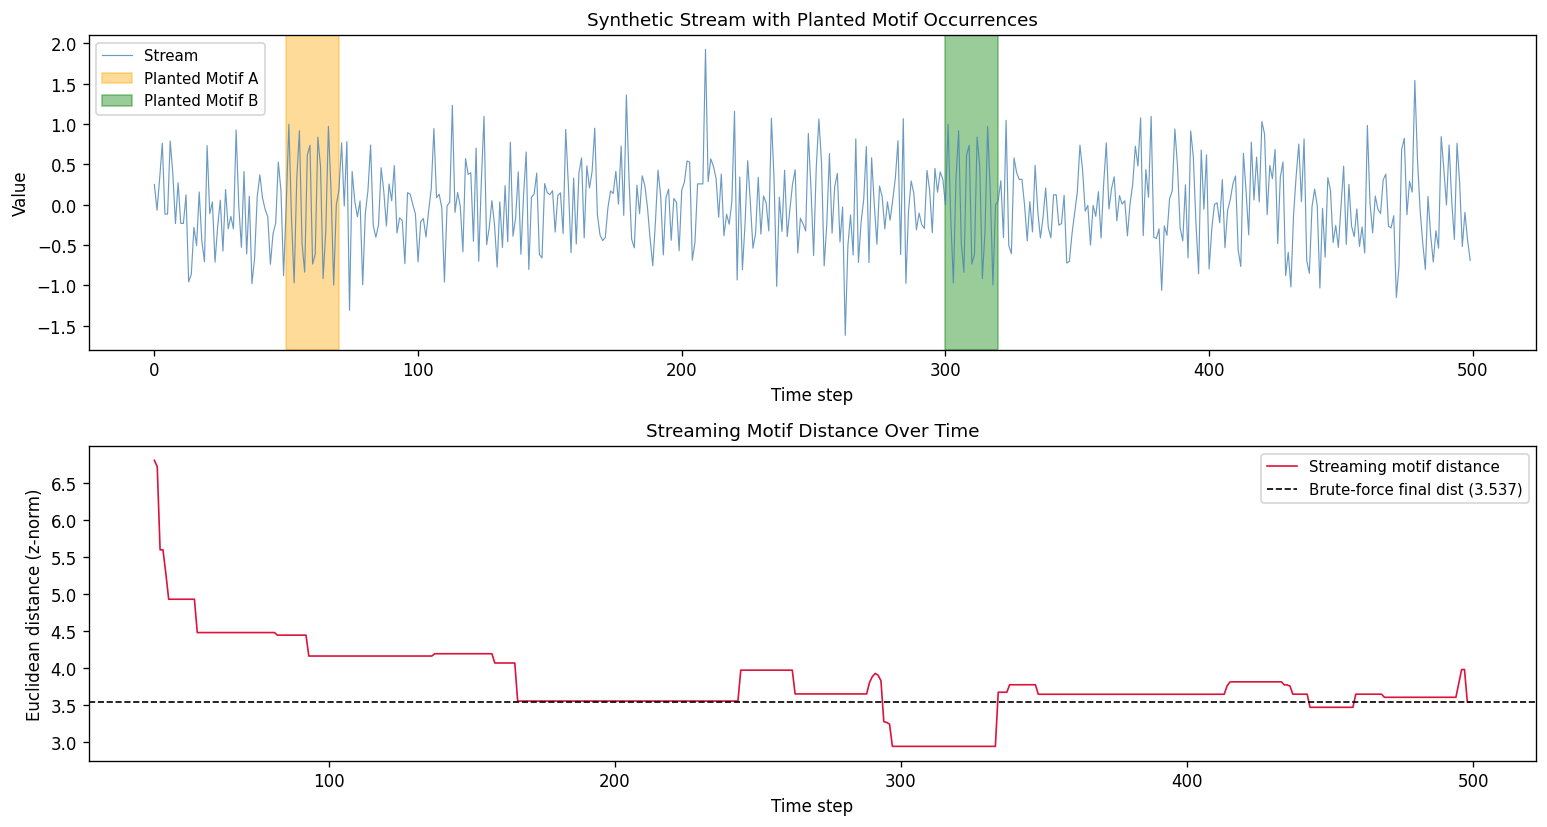

Plot saved: results/task_2_2_motif_distance.png


In [7]:
# ─── Visualisation: Motif distance over time (streaming) ─────────────────────
# This is the primary visualisation for Task 2.2, saved to results/.

fig, axes = plt.subplots(2, 1, figsize=(13, 7), dpi=120)

axes[0].plot(stream, color='steelblue', linewidth=0.7, alpha=0.8, label='Stream')
axes[0].axvspan(50, 50 + m, color='orange', alpha=0.4, label='Planted Motif A')
axes[0].axvspan(300, 300 + m, color='green', alpha=0.4, label='Planted Motif B')
axes[0].set_title('Synthetic Stream with Planted Motif Occurrences', fontsize=11)
axes[0].set_xlabel('Time step'); axes[0].set_ylabel('Value'); axes[0].legend(fontsize=9)

axes[1].plot(motif_distances_stream, color='crimson', linewidth=1.0, label='Streaming motif distance')
axes[1].axhline(bf_dist, color='black', linestyle='--', linewidth=1.0, label=f'Brute-force final dist ({bf_dist:.3f})')
axes[1].set_title('Streaming Motif Distance Over Time', fontsize=11)
axes[1].set_xlabel('Time step'); axes[1].set_ylabel('Euclidean distance (z-norm)'); axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('results/task_2_2_motif_distance.png', dpi=120, bbox_inches='tight')
plt.show()
print("Plot saved: results/task_2_2_motif_distance.png")
